This notebook demonstrates a simple linear regression analysis using R to model Salary based on Years of Experience.

This notebook is calculating Mean Squared Error (MSE), fitted line slope, fitted line intercept, and correlation coefficient using R.

MSE allows for the comparison of the real data against predictions made by the model. The fit of the model is inferior because of the large MSE of 17523844.08. Note how the squaring in y squared units from the equation MSE = (1/n) * Σ (yᵢ - ŷᵢ)² drives attention toward bigger MSE values. n represents the observation number, yᵢ represents the real value, and ŷᵢ represents the predicted value made by the model.

The slope is 8285.29, which represents the quantity by which the line increases by y compared against a singular x unit increase.

The intercept is 29203.52 at x = 0, which represents a constant, base y value.

The correlation value is 0.89, which represents a sizeable, positive relationship.

In [24]:
dataset <- read.csv("regression_data.csv")

`geom_smooth()` using formula = 'y ~ x'
Saving 7 x 7 in image
`geom_smooth()` using formula = 'y ~ x'


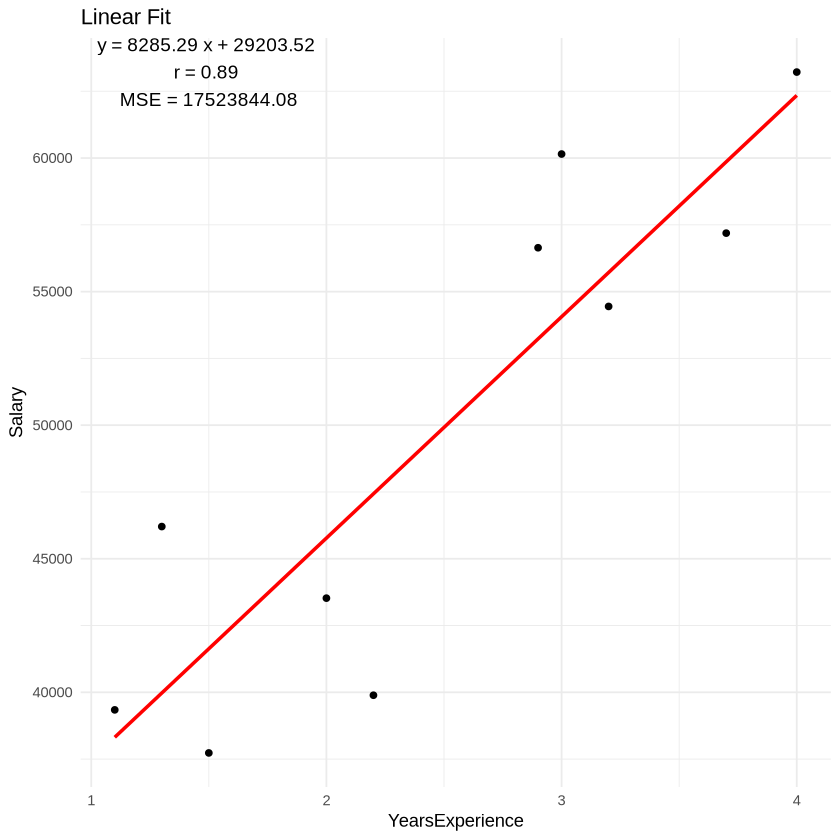

In [25]:
library(ggplot2)

# Fit model
model <- lm(Salary ~ YearsExperience, data = dataset)
slope <- coef(model)[2]
intercept <- coef(model)[1]
r <- cor(dataset$YearsExperience, dataset$Salary)
pred <- predict(model)
mse <- mean((dataset$Salary - pred)^2)

# Plot
ggplot(dataset, aes(x = YearsExperience, y = Salary)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  annotate("text", x = 1.5, y = max(dataset$Salary) - 0.5,
           label = paste("y =", round(slope, 2), "x +", round(intercept, 2),
                         "\nr =", round(r, 2), "\nMSE =", round(mse, 2)),
           size = 4) +
  labs(title = "Linear Fit",
       x = "YearsExperience", y = "Salary") +
  theme_minimal()

ggsave("regression_plot_r.png")